In [1]:
import numpy as np

date = "251128"
dl_folder = f"D:/Python_TK_3/datas/{date}_DL"

dl_number = "Vis_angle_multi_01"

look_frame = 20
models = 5

In [2]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_time(data: np.ndarray) -> np.ndarray:
    """
    各時間フレームごとに VIF（分散インフレーション因子）を計算する。

    Parameters
    ----------
    data : np.ndarray
        shape = (n_datasets, T, R)
        n_datasets: サンプル数
        T         : タイムフレーム数
        R         : 神経領域数

    Returns
    -------
    vif_array : np.ndarray
        shape = (T, R)
        各時間フレーム t における各領域 i の VIF 値
    """
    n, T, R = data.shape
    vif_array = np.zeros((T, R), dtype=float)

    for t in range(T):
        # t フレーム目のデータを DataFrame 化
        df = pd.DataFrame(
            data[:, t, :],
            columns=[f"region_{i}" for i in range(R)]
        )
        # 各列 i について VIF を計算
        vif_array[t, :] = [
            variance_inflation_factor(df.values, i)
            for i in range(R)
        ]

    return vif_array

# 使い方の例
# data = np.random.randn(100, 11, 22)  # サンプル数100、11フレーム、22領域 のダミーデータ
# vif_results = compute_vif_time(data)
# print(vif_results.shape)  # → (11, 22)
# print(vif_results)        # 各時間フレームごとの VIF 行列


In [3]:
import tqdm
import numpy as np
import os

vif_array = []
min_vif = []
max_vif = []
ave_vif = []
for n in tqdm.tqdm(range(5)):
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")

    input_train = np.load(f"{model_dir}/{date}_{dl_number}_train_features.npy")
    #trainY = np.load(f"{model_dir}/{date}_{shap_number}_train_targets.npy")
    #input_valid = np.load(f"{model_dir}/{date}_{shap_number}_valid_features.npy")
    #validY = np.load(f"{model_dir}/{date}_{shap_number}_valid_targets.npy")
    #input_test = np.load(f"{model_dir}/{date}_{shap_number}_test_features.npy")
    #testY = np.load(f"{model_dir}/{date}_{shap_number}_test_targets.npy")
    #input_train = input_train[:, :, :9]

    vif_array_2d = compute_vif_time(input_train)
    vif_array.append(vif_array_2d)
    min_vif.append(min(vif_array_2d.reshape(-1)))
    max_vif.append(max(vif_array_2d.reshape(-1)))
    ave_vif.append(np.mean(vif_array_2d.reshape(-1)))

vif_array = np.array(vif_array)
min_vif = np.array(min_vif)
max_vif = np.array(max_vif)
ave_vif = np.array(ave_vif)

print(vif_array.shape, max_vif.shape)

100%|██████████| 5/5 [00:26<00:00,  5.31s/it]

(5, 31, 23) (5,)


In [4]:
fs = 20

look_frame = 30

# 初期値
start_value = -1.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [5]:
roi_number = []
for ic in range(vif_array_2d.shape[1]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [6]:
mean_vif_array = np.mean(vif_array, axis=0)
print(mean_vif_array.shape)

(31, 23)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def vif_show(vif_array):
    plt.figure(figsize=(4, 4))
    sns.heatmap(vif_array.transpose(), cmap='vlag', vmin=0, vmax=20)
    #sns.heatmap(vif_array.transpose(), cmap='icefire')
        #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
        #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
        # Tickの位置
    ticks = np.arange(0.5, look_frame + 1.0, 10)
        # 同じ数のラベルを作る
    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels, rotation=0)
    plt.yticks( np.arange(0.5, mean_vif_array.shape[1]+0.5), roi_number, rotation=0)
    plt.axvspan(30.45, 30.55, color='black', alpha=1)
    plt.title("VIF")
    plt.xlabel("Time (s)")
    plt.ylabel("IC #")
    plt.show()

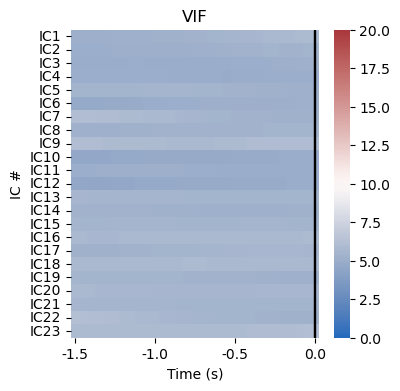

In [25]:
vif_show(mean_vif_array)

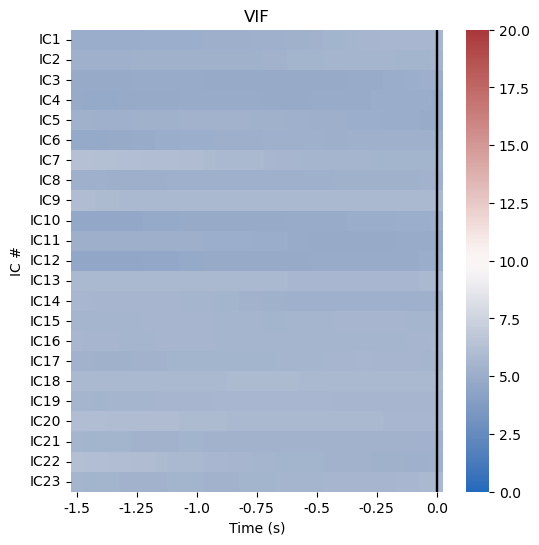

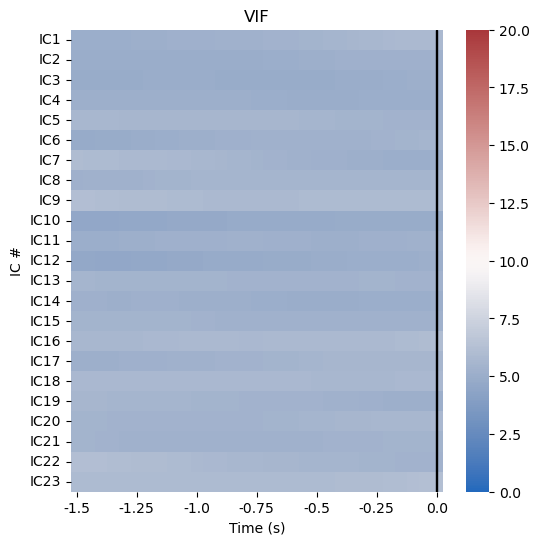

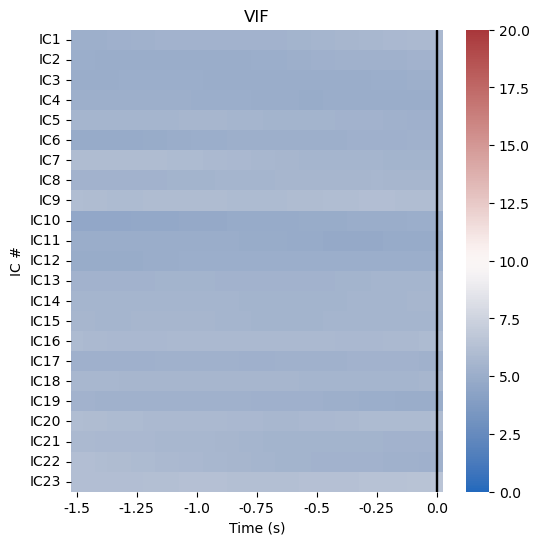

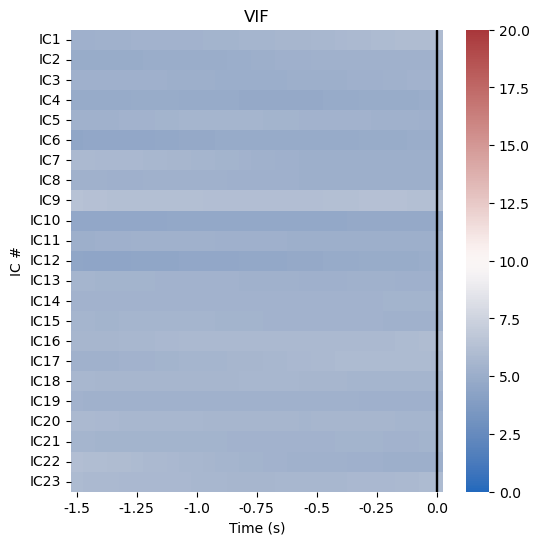

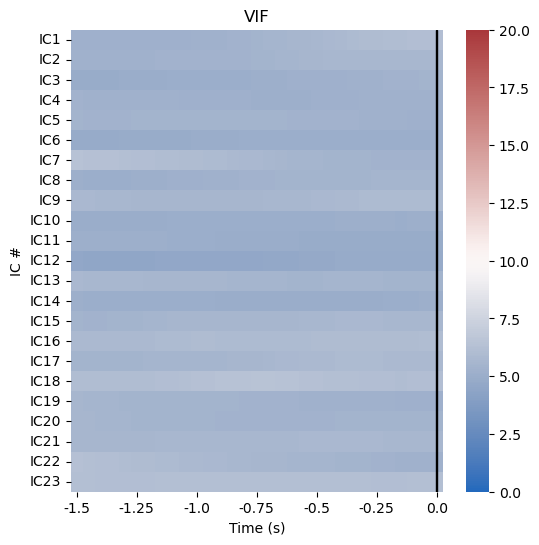

In [13]:
for model in range(vif_array.shape[0]):
    vif_show(vif_array[model])

In [10]:
print(min(min_vif))
print(max(max_vif))
print(np.mean(ave_vif))

4.435961602998975
6.51261567706584
5.381037741241644


In [9]:
import numpy as np

input_train = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_features.npy")
trainY      = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_targets.npy")

input_valid = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_features.npy", )
validY      = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_targets.npy")

input_test  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_features.npy")
testY       = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_targets.npy")

print(input_train.shape)
print(trainY.shape)

print(input_valid.shape)
print(validY.shape)

print(input_test.shape)
print(testY.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Python_TK_3/datas/250710_DL/model_SsStim_evoked_multi_01/250710_SsStim_evoked_multi_01_train_features.npy'

In [3]:
flatted_feature = input_train.reshape(input_train.shape[0], input_train.shape[1]*input_train.shape[2])
print(flatted_feature.shape)

(672, 253)


In [10]:
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_numpy(X: np.ndarray) -> np.ndarray:
    """
    X: numpy array of shape (n_samples, n_features)
    return: numpy array of shape (n_features,) containing VIF values
    """
    n_features = X.shape[1]
    vif = np.zeros(n_features, dtype=float)
    for i in range(n_features):
        vif[i] = variance_inflation_factor(X, i)
    return vif

# --- 使い方例 ---
# X が shape=(n_samples, 242) の numpy 配列の場合
vif_array = compute_vif_numpy(flatted_feature)
#print(vif_array)         # VIF 値の numpy 配列
print(vif_array.shape)   # (242,)


NameError: name 'flatted_feature' is not defined

In [5]:
print(min(vif_array))
print(max(vif_array))
print(np.mean(vif_array))

191.3856846160921
1982.019917952057
623.9746748535143


In [11]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_time(data: np.ndarray) -> np.ndarray:
    """
    各時間フレームごとに VIF（分散インフレーション因子）を計算する。

    Parameters
    ----------
    data : np.ndarray
        shape = (n_datasets, T, R)
        n_datasets: サンプル数
        T         : タイムフレーム数
        R         : 神経領域数

    Returns
    -------
    vif_array : np.ndarray
        shape = (T, R)
        各時間フレーム t における各領域 i の VIF 値
    """
    n, T, R = data.shape
    vif_array = np.zeros((T, R), dtype=float)

    for t in range(T):
        # t フレーム目のデータを DataFrame 化
        df = pd.DataFrame(
            data[:, t, :],
            columns=[f"region_{i}" for i in range(R)]
        )
        # 各列 i について VIF を計算
        vif_array[t, :] = [
            variance_inflation_factor(df.values, i)
            for i in range(R)
        ]

    return vif_array

# 使い方の例
# data = np.random.randn(100, 11, 22)  # サンプル数100、11フレーム、22領域 のダミーデータ
# vif_results = compute_vif_time(data)
# print(vif_results.shape)  # → (11, 22)
# print(vif_results)        # 各時間フレームごとの VIF 行列


In [7]:
vif_array_2d = compute_vif_time(input_train)
print(vif_array_2d.shape)

(11, 23)


In [8]:
print(min(vif_array_2d.reshape(-1)))
print(max(vif_array_2d.reshape(-1)))
print(np.mean(vif_array_2d.reshape(-1)))

1.2772342118351352
2.8110496941345207
1.8594289245711466


In [9]:
fs = 20

look_frame = 10

# 初期値
start_value = -0.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [10]:
roi_number = []
for ic in range(vif_array_2d.shape[1]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [11]:
vif_array2 = vif_array.reshape(look_frame+1, int(vif_array.shape[0]/(look_frame+1)))
print(vif_array2.shape)

(11, 23)


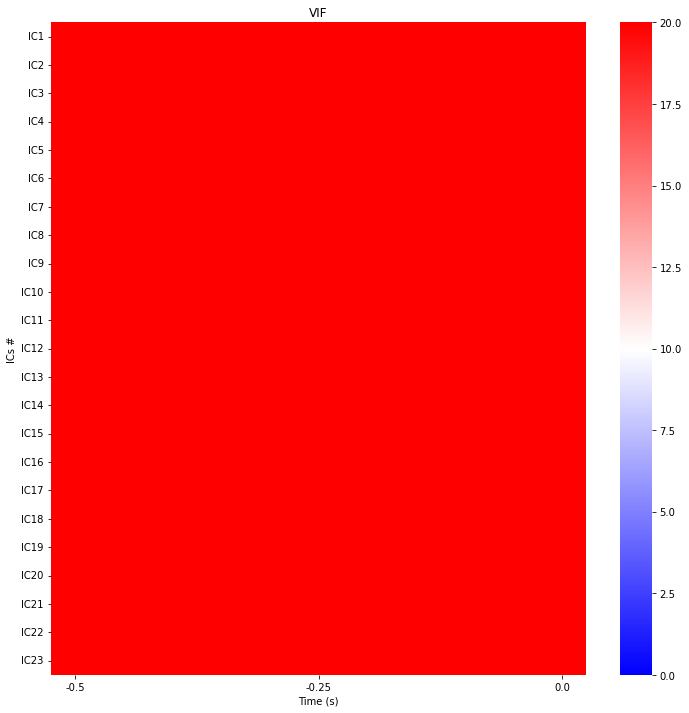

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(vif_array2.transpose(), cmap='bwr', vmin=0, vmax=20)
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
labels = np.linspace(start_value, 0, len(ticks))
plt.xticks(ticks, labels)
plt.yticks( np.arange(0.5, vif_array2.shape[1]+0.5), roi_number, rotation=0)
#plt.axvspan(10.45, 10.55, color='red', alpha=1)
plt.title("VIF")
plt.xlabel("Time (s)")
plt.ylabel("ICs #")
plt.show()

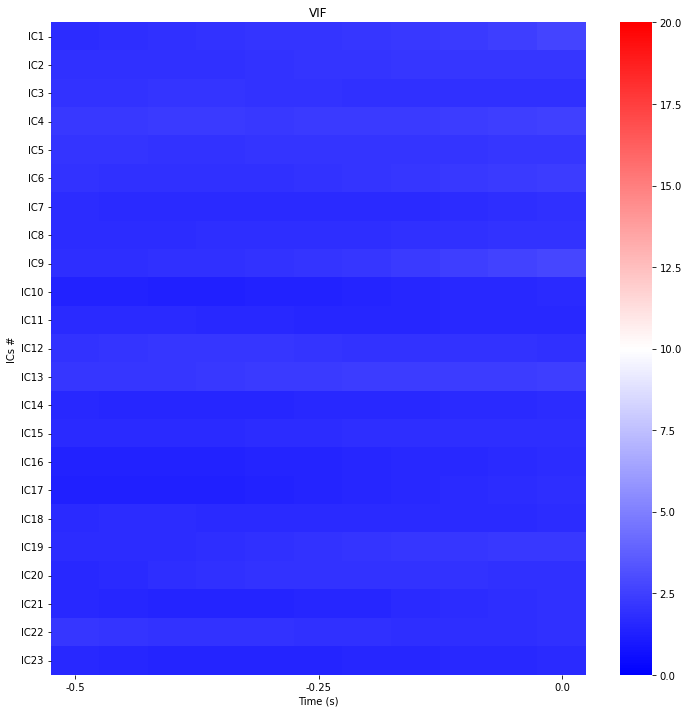

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(vif_array_2d.transpose(), cmap='bwr', vmin=0, vmax=20)
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
labels = np.linspace(start_value, 0, len(ticks))
plt.xticks(ticks, labels)
plt.yticks( np.arange(0.5, vif_array_2d.shape[1]+0.5), roi_number, rotation=0)
#plt.axvspan(10.45, 10.55, color='red', alpha=1)
plt.title("VIF")
plt.xlabel("Time (s)")
plt.ylabel("ICs #")
plt.show()